In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

In [12]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)


In [13]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [14]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [16]:
df['species'] = iris.target

In [22]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [25]:
df[df['species'] == 1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [88]:
df.shape

(150, 5)

In [89]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [90]:
#df.describe()

## Visualizations

In [31]:
# sns.pairplot(df , hue="species")
df0 = df[:50]
df1 = df[50:100]
df2 = df[100:]
df0.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Sepal length vs Sepal width (sesosa vs versicolor)

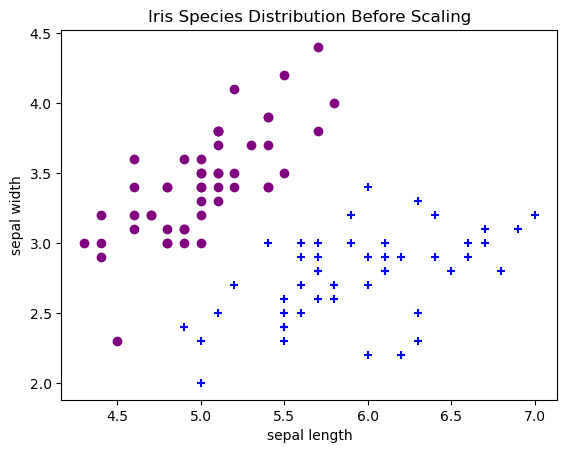

In [156]:
plt.scatter(df0["sepal length (cm)"] , df0["sepal width (cm)"] ,  color = "purple" , marker = 'o' ) #sesosa
plt.scatter(df1["sepal length (cm)"] , df1["sepal width (cm)"] ,  color = "blue" , marker = '+' ) #versicolor
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.title("Iris Species Distribution Before Scaling")
plt.savefig('./Visualizations/Iris Species Distribution Before Scaling.png', dpi=300, bbox_inches="tight")
plt.show()

## petal length vs petal width (sesosa vs versicolor)

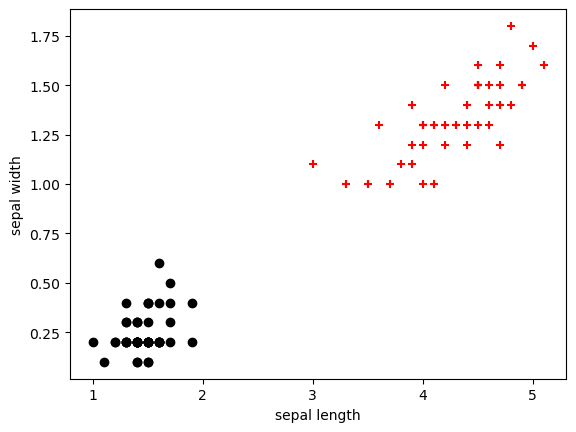

In [44]:
plt.scatter(df0["petal length (cm)"] , df0["petal width (cm)"] ,  color = "black" , marker = 'o' ) #sesosa
plt.scatter(df1["petal length (cm)"] , df1["petal width (cm)"] ,  color = "red" , marker = '+' ) #versicolor
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.show()

## Splitting

In [134]:
X = iris.data # (what the model learns FROM)
y =  iris.target # (what the model learns TO PREDICT)

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held out for testing
    random_state=42,    # Reproducible split every run
    stratify=y          # Keep class proportions equal in both sets
)

In [150]:
#to check the splitting
len(X_train)
len(y_test)

30

## Feature Scaling (StandardScaler)

In [137]:
# This learns the mean and std of each feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # FIT on training data ONLY — never on test data
X_test = scaler.transform(X_test)

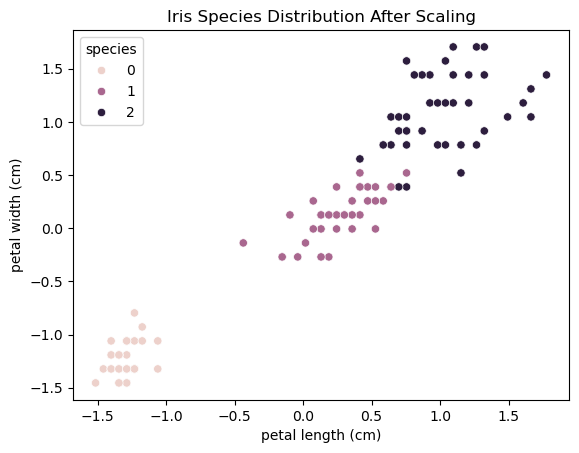

In [157]:
X_train_scaled = pd.DataFrame(X_train , columns=iris.feature_names)
X_train_scaled
X_train_scaled["species"] = y_train 
sns.scatterplot(
    data = X_train_scaled ,
    x = "petal length (cm)" ,
    y = "petal width (cm)" ,
    hue = "species"
)
plt.title("Iris Species Distribution After Scaling")
plt.savefig('./Visualizations/Iris Species Distribution After Scaling.png', dpi=300, bbox_inches="tight")

## Build and Train the Model

In [119]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Predict and Evaluate

In [120]:
# Predict: Apply logic to unseen test data
model.score(X_test , y_test)


1.0

In [121]:
predictions = model.predict(X_test)
predictions

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [122]:
# Metrics
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(classification_report(y_test, predictions,
                            target_names=iris.target_names))

Accuracy: 1.0000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [123]:
cm = confusion_matrix(y_test, predictions)
cm

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])

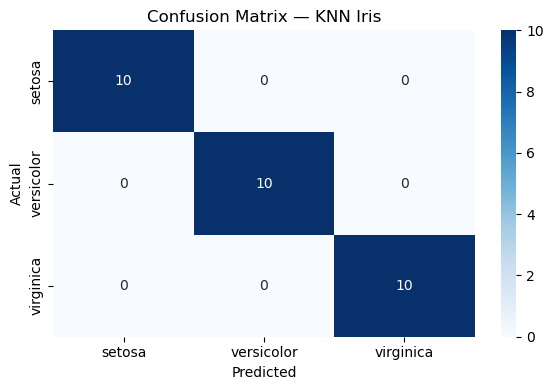

In [153]:
# Confusion Matrix visualisation
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — KNN Iris')
plt.tight_layout()
plt.savefig('./Visualizations/Confusion Matrix — KNN Iris.png', dpi=300, bbox_inches="tight")
plt.show()

## Find Optimal K (Elbow Method) 

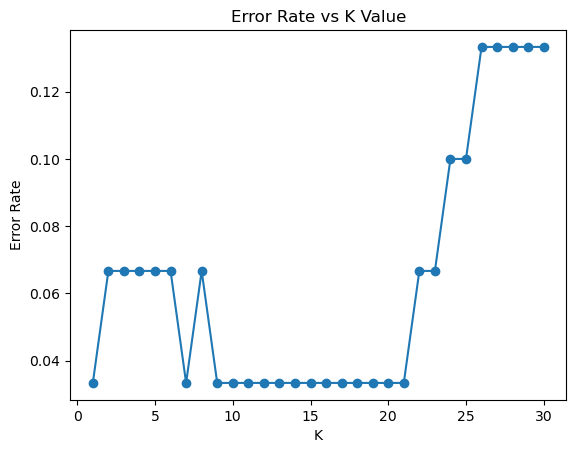

In [154]:
error_rates = []
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.plot(range(1,31), error_rates, marker='o')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.savefig('./Visualizations/Error Rate vs K Value.png', dpi=300, bbox_inches="tight")
plt.show()